# Домен: Метеорологія (Jena Climate)
Цільова змінна: температура повітря `T (degC)`. Горизонт прогнозу: 1 година.

## 1. Розвідувальний аналіз даних (EDA)

Файл знайдено за шляхом: /kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv
Завантаження даних (це може зайняти кілька секунд)...
Дані успішно підготовлено! Кількість годин для аналізу: 70041


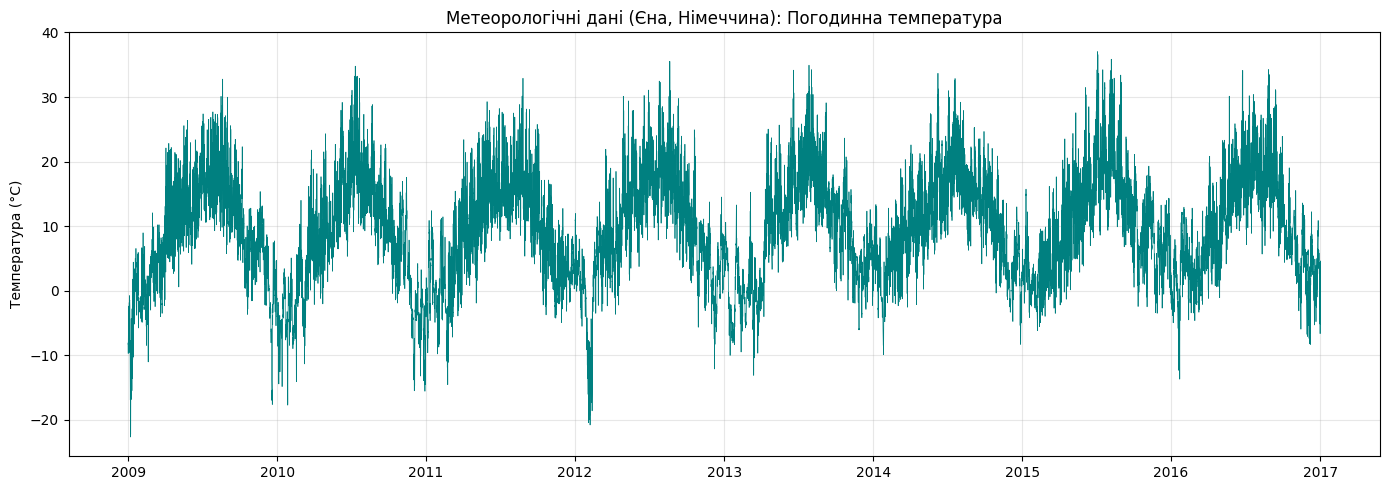


--- Тест ADF для: Погодинна Температура ---
ADF Statistic: -8.4999
p-value: 1.2463e-13
Висновок: Ряд стаціонарний (H0 відхилено). Ряд не потребує диференціювання.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import os

# 1. Автоматичний пошук точного шляху до файлу в середовищі Kaggle
file_path = ""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'jena_climate' in filename.lower() and filename.endswith('.csv'):
            file_path = os.path.join(dirname, filename)
            break

if not file_path:
    print("Помилка: Файл не знайдено. Переконайтеся, що ви додали датасет через 'Add Data'.")
else:
    print(f"Файл знайдено за шляхом: {file_path}")
    
    # 2. Завантаження даних
    print("Завантаження даних (це може зайняти кілька секунд)...")
    df_weather = pd.read_csv(file_path)
    
    # Форматування часу та встановлення індексу
    df_weather['Date Time'] = pd.to_datetime(df_weather['Date Time'], format='%d.%m.%Y %H:%M:%S')
    df_weather.set_index('Date Time', inplace=True)
    
    # 3. Ресемплінг: перехід від 10-хвилинних інтервалів до 1-годинних (середнє значення)
    df_hourly = df_weather.resample('1h').mean()
    df_hourly.dropna(inplace=True)
    
    target_col = 'T (degC)' # Цільова змінна - температура в градусах Цельсія
    
    print(f"Дані успішно підготовлено! Кількість годин для аналізу: {len(df_hourly)}")
    
    # 4. Візуалізація ряду
    plt.figure(figsize=(14, 5))
    plt.plot(df_hourly.index, df_hourly[target_col], color='teal', linewidth=0.5)
    plt.title('Метеорологічні дані (Єна, Німеччина): Погодинна температура')
    plt.ylabel('Температура (°C)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 5. Тест Дікі-Фуллера
    def check_stationarity(series, name):
        print(f"\n--- Тест ADF для: {name} ---")
        result = adfuller(series)
        print(f'ADF Statistic: {result[0]:.4f}')
        print(f'p-value: {result[1]:.4e}')
        if result[1] <= 0.05:
            print("Висновок: Ряд стаціонарний (H0 відхилено). Ряд не потребує диференціювання.")
        else:
            print("Висновок: Ряд НЕ стаціонарний (H0 не відхилено).")

    check_stationarity(df_hourly[target_col], "Погодинна Температура")

In [4]:
# Перегляд доступних колонок
print("Список доступних ознак (колонок) у датасеті Єни:")
for i, col in enumerate(df_hourly.columns):
    print(f"{i+1}. {col}")

# Вивід перших 3 рядків для візуального ознайомлення
print("\n--- Перші 3 рядки даних ---")
print(df_hourly.head(3))

# Базова фізична статистика (щоб побачити діапазони значень)
print("\n--- Базова статистика (опис) ---")
print(df_hourly.describe().T[['count', 'mean', 'min', 'max', 'std']])

Список доступних ознак (колонок) у датасеті Єни:
1. p (mbar)
2. T (degC)
3. Tpot (K)
4. Tdew (degC)
5. rh (%)
6. VPmax (mbar)
7. VPact (mbar)
8. VPdef (mbar)
9. sh (g/kg)
10. H2OC (mmol/mol)
11. rho (g/m**3)
12. wv (m/s)
13. max. wv (m/s)
14. wd (deg)

--- Перші 3 рядки даних ---
                     p (mbar)  T (degC)    Tpot (K)  Tdew (degC)     rh (%)  \
Date Time                                                                     
2009-01-01 00:00:00   996.528 -8.304000  265.118000    -9.120000  93.780000   
2009-01-01 01:00:00   996.525 -8.065000  265.361667    -8.861667  93.933333   
2009-01-01 02:00:00   996.745 -8.763333  264.645000    -9.610000  93.533333   

                     VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  \
Date Time                                                                  
2009-01-01 00:00:00      3.260000      3.058000      0.202000   1.910000   
2009-01-01 01:00:00      3.323333      3.121667      0.201667   1.951667   
2009-01-01 02:00:00

## 2. Підготовка даних та Feature Engineering

In [5]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

print("Етап 1: Повна підготовка метеорологічних даних...")

# 1. Пошук файлу в середовищі Kaggle
file_path = ""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if 'jena_climate' in filename.lower() and filename.endswith('.csv'):
            file_path = os.path.join(dirname, filename)
            break

if not file_path:
    print("Помилка: Файл не знайдено.")
else:
    # 2. Завантаження та базовий ресемплінг
    df_weather = pd.read_csv(file_path)
    df_weather['Date Time'] = pd.to_datetime(df_weather['Date Time'], format='%d.%m.%Y %H:%M:%S')
    df_weather.set_index('Date Time', inplace=True)
    
    df_hourly = df_weather.resample('1h').mean()
    df_hourly.dropna(inplace=True)
    
    # 3. Очищення аномалій
    df_hourly['wv (m/s)'] = df_hourly['wv (m/s)'].replace(-9999.0, 0)
    df_hourly['max. wv (m/s)'] = df_hourly['max. wv (m/s)'].replace(-9999.0, 0)
    
    # 4. Вибір цільової змінної та екзогенних ознак
    target_col = 'T (degC)'
    features_to_use = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)']
    df_selected = df_hourly[features_to_use].copy()
    
    # 5. Feature Engineering (Створення ознак БЕЗ витоку даних)
    lookback = 24
    df_ml = pd.DataFrame(index=df_selected.index)
    
    # Цільова змінна (те, що прогнозуємо на час t)
    df_ml['target_T'] = df_selected[target_col] 
    
    # Лаги (історія за попередні 24 години для КОЖНОГО з 4 параметрів)
    for col in features_to_use:
        for i in range(1, lookback + 1):
            df_ml[f'{col}_lag_{i}'] = df_selected[col].shift(i)
            
    # Додаємо годину доби як ознаку (фіксуємо добовий цикл)
    df_ml['hour'] = df_ml.index.hour
    
    # Видаляємо порожні рядки, які утворилися через зсув .shift()
    df_ml.dropna(inplace=True)
    
    # 6. Формування матриць X (ознаки) та y (ціль)
    X_w = df_ml.drop(['target_T'], axis=1).values
    y_w = df_ml['target_T'].values
    
    # 7. Розділення на Train та Test (Тест = останні 30 днів = 720 годин)
    test_size = 720
    train_idx_w = len(df_ml) - test_size
    
    X_train_w, X_test_w = X_w[:train_idx_w], X_w[train_idx_w:]
    y_train_w, y_test_w = y_w[:train_idx_w], y_w[train_idx_w:]
    
    # 8. Масштабування даних
    scaler_xw = StandardScaler()
    scaler_yw = StandardScaler()
    
    X_train_ws = scaler_xw.fit_transform(X_train_w)
    X_test_ws = scaler_xw.transform(X_test_w)
    
    # y масштабуємо для нейромереж (для дерев це не обов'язково, але зручно мати)
    y_train_ws = scaler_yw.fit_transform(y_train_w.reshape(-1, 1))
    y_test_ws = scaler_yw.transform(y_test_w.reshape(-1, 1))
    
    # 9. Формування 3D-тензорів для рекурентних та згорткових мереж (LSTM, 1D-CNN)
    X_train_w3d = X_train_ws.reshape((X_train_ws.shape[0], 1, X_train_ws.shape[1]))
    X_test_w3d = X_test_ws.reshape((X_test_ws.shape[0], 1, X_test_ws.shape[1]))

    print("Підготовку даних завершено успішно!")
    print(f"Кількість ознак (features) для кожної години: {X_train_ws.shape[1]}")
    print(f"Розмір тренувальної вибірки: {X_train_ws.shape[0]} годин")
    print(f"Розмір тестової вибірки: {X_test_ws.shape[0]} годин")

Етап 1: Повна підготовка метеорологічних даних...
Підготовку даних завершено успішно!
Кількість ознак (features) для кожної години: 97
Розмір тренувальної вибірки: 69297 годин
Розмір тестової вибірки: 720 годин


## 3. Базові моделі (Baselines)

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Для тестової вибірки беремо останні 30 днів (720 годин)
test_size = 24 * 30
train_data = df_hourly.iloc[:-test_size]
test_data = df_hourly.iloc[-test_size:].copy()

true_values = test_data[target_col].values

# 1. Naive Forecast: температура наступної години = температура цієї години (t-1)
test_data['naive_pred'] = df_hourly[target_col].shift(1).iloc[-test_size:].values

# 2. Seasonal Naive: температура = температура в цей же час вчора (t-24)
test_data['s_naive_pred'] = df_hourly[target_col].shift(24).iloc[-test_size:].values

# Функція для розрахунку MAE та RMSE
def print_weather_metrics(name, true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    print(f"{name:<15} | MAE: {mae:5.2f} °C | RMSE: {rmse:5.2f} °C")

print("--- БАЗОВІ МОДЕЛІ (МЕТЕОРОЛОГІЯ) ---")
print_weather_metrics("Naive (t-1)", true_values, test_data['naive_pred'])
print_weather_metrics("S. Naive (t-24)", true_values, test_data['s_naive_pred'])

--- БАЗОВІ МОДЕЛІ (МЕТЕОРОЛОГІЯ) ---
Naive (t-1)     | MAE:  0.51 °C | RMSE:  0.75 °C
S. Naive (t-24) | MAE:  2.53 °C | RMSE:  3.28 °C


## 4. Етап 1: Моделі з базовими конфігураціями
Усі моделі навчаються з мінімально необхідними параметрами для отримання baseline результатів.

### 4.1. XGBoost

In [6]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Етап 2.1: Навчання XGBoost (Метеорологія)...")

# Ініціалізація та навчання моделі
model_xgb_w = xgb.XGBRegressor(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42
)

# Для дерев рішень y_train_w можна не масштабувати, 
# тому передаємо оригінальні значення температури
model_xgb_w.fit(X_train_ws, y_train_w) 
xgb_pred_w = model_xgb_w.predict(X_test_ws)

# Оцінка результатів
mae_xgb = mean_absolute_error(y_test_w, xgb_pred_w)
rmse_xgb = np.sqrt(mean_squared_error(y_test_w, xgb_pred_w))

print("\n--- ПОРІВНЯННЯ З БАЗОВИМ РІВНЕМ ---")
print(f"Naive (t-1)  | MAE: (див. результати baseline) | (Фізична інерція)")
print("-" * 45)
print(f"XGBoost      | MAE: {mae_xgb:5.2f} °C | RMSE: {rmse_xgb:5.2f} °C")

Етап 2.1: Навчання XGBoost (Метеорологія)...

--- ПОРІВНЯННЯ З БАЗОВИМ РІВНЕМ ---
Naive (t-1)  | MAE:  0.51 °C | (Фізична інерція)
---------------------------------------------
XGBoost      | MAE:  0.38 °C | RMSE:  0.52 °C


### 4.2. SVR (Support Vector Regression)

In [8]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Етап 2.2: Навчання SVR на збільшеній вибірці (Метеорологія)...")

# Збільшуємо тренувальну вибірку до 40 000 годин
train_subset = 40000

# Додаємо явно gamma='scale' для кращої роботи з 97 вимірами
model_svr_w = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')

print(f"Початок навчання на {train_subset} рядках. Зачекайте 1-3 хвилини...")
model_svr_w.fit(X_train_ws[-train_subset:], y_train_w[-train_subset:])
svr_pred_w = model_svr_w.predict(X_test_ws)

# Оцінка результатів
mae_svr = mean_absolute_error(y_test_w, svr_pred_w)
rmse_svr = np.sqrt(mean_squared_error(y_test_w, svr_pred_w))

print("\n--- ОНОВЛЕНИЙ РЕЗУЛЬТАТ SVR ---")
print(f"SVR (40k)    | MAE: {mae_svr:5.2f} °C | RMSE: {rmse_svr:5.2f} °C")

Етап 2.2: Навчання SVR на збільшеній вибірці (Метеорологія)...
Початок навчання на 40000 рядках. Зачекайте 1-3 хвилини...

--- ОНОВЛЕНИЙ РЕЗУЛЬТАТ SVR ---
SVR (40k)    | MAE:  0.60 °C | RMSE:  0.84 °C


### 4.3. Нейронні мережі (MLP, LSTM, 1D-CNN)

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Фіксуємо випадковість для стабільності
tf.keras.utils.set_random_seed(42)

print("Етап 2.3: Навчання нейромереж (Метеорологія). Зачекайте 1-2 хвилини...\n")

def get_es():
    return EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 1. Багатошаровий перцептрон (MLP)
model_mlp_w = Sequential([
    Input(shape=(X_train_ws.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model_mlp_w.compile(optimizer='adam', loss='mse')
model_mlp_w.fit(X_train_ws, y_train_ws, epochs=50, batch_size=256, validation_split=0.1, callbacks=[get_es()], verbose=0)
mlp_pred_ws = model_mlp_w.predict(X_test_ws, verbose=0)
mlp_pred_w = scaler_yw.inverse_transform(mlp_pred_ws).flatten()

# 2. Рекурентна мережа (LSTM)
model_lstm_w = Sequential([
    Input(shape=(1, X_train_ws.shape[1])),
    LSTM(64, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model_lstm_w.compile(optimizer='adam', loss='mse')
model_lstm_w.fit(X_train_w3d, y_train_ws, epochs=50, batch_size=256, validation_split=0.1, callbacks=[get_es()], verbose=0)
lstm_pred_ws = model_lstm_w.predict(X_test_w3d, verbose=0)
lstm_pred_w = scaler_yw.inverse_transform(lstm_pred_ws).flatten()

# 3. Згорткова мережа (1D-CNN)
model_cnn_w = Sequential([
    Input(shape=(1, X_train_ws.shape[1])),
    Conv1D(filters=64, kernel_size=1, activation='relu'),
    Dropout(0.2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])
model_cnn_w.compile(optimizer='adam', loss='mse')
model_cnn_w.fit(X_train_w3d, y_train_ws, epochs=50, batch_size=256, validation_split=0.1, callbacks=[get_es()], verbose=0)
cnn_pred_ws = model_cnn_w.predict(X_test_w3d, verbose=0)
cnn_pred_w = scaler_yw.inverse_transform(cnn_pred_ws).flatten()

# Оцінка результатів
def print_dl_metrics(name, pred):
    mae = mean_absolute_error(y_test_w, pred)
    rmse = np.sqrt(mean_squared_error(y_test_w, pred))
    print(f"{name:<12} | MAE: {mae:5.2f} °C | RMSE: {rmse:5.2f} °C")

print("--- ФІНАЛЬНІ РЕЗУЛЬТАТИ DEEP LEARNING ---")
print_dl_metrics("MLP", mlp_pred_w)
print_dl_metrics("LSTM", lstm_pred_w)
print_dl_metrics("1D-CNN", cnn_pred_w)

2026-03-23 15:20:44.204395: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774279244.433860      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774279244.497642      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774279245.035939      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774279245.035970      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774279245.035973      55 computation_placer.cc:177] computation placer alr

Етап 2.3: Навчання нейромереж (Метеорологія). Зачекайте 1-2 хвилини...



I0000 00:00:1774279270.386916      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774279270.389409      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1774279272.773121     191 service.cc:152] XLA service 0x7ab0cc00ad30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774279272.773151     191 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774279272.773155     191 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774279273.052515     191 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774279274.270953     191 device_compiler.h:188] Compiled clust

--- ФІНАЛЬНІ РЕЗУЛЬТАТИ DEEP LEARNING ---
MLP          | MAE:  0.86 °C | RMSE:  1.10 °C
LSTM         | MAE:  0.64 °C | RMSE:  0.83 °C
1D-CNN       | MAE:  1.11 °C | RMSE:  1.39 °C


### 4.4. Класичні статистичні моделі (ARIMA, SARIMA, Holt-Winters)

In [11]:
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')

print("Етап 2.5: Навчання класичних статистичних моделей (Метеорологія)...\n")

# Для статистики нам потрібен лише одновимірний ряд цільової змінної (Температура).
# Беремо останні 2000 годин (більше 2.5 місяців), чого цілком достатньо для статистики
train_stat = y_train_w[-2000:]
test_stat = y_test_w

# 1. ARIMA (без сезонного компонента)
print("1. Навчання ARIMA(3,0,3)...")
model_arima = SARIMAX(train_stat, order=(3, 0, 3), trend='c')
res_arima = model_arima.fit(disp=False)
# Швидкий прогноз на 1 крок вперед для всіх 720 годин тесту
pred_arima = res_arima.apply(test_stat).fittedvalues

# 2. SARIMA (з додаванням добової сезонності 24 години)
print("2. Навчання SARIMA(1,0,1)(1,0,1,24)... (зачекайте близько хвилини)")
model_sarima = SARIMAX(train_stat, order=(1, 0, 1), seasonal_order=(1, 0, 1, 24), trend='c')
res_sarima = model_sarima.fit(disp=False)
pred_sarima = res_sarima.apply(test_stat).fittedvalues

# 3. Holt-Winters (Експоненційне згладжування)
print("3. Прогноз Holt-Winters (Rolling forecast)...")
hw_preds = []
history_hw = list(train_stat)

# Для моделі Хольта-Вінтерса ми використовуємо ковзне вікно (навчаємо на останніх 5 днях)
# Це дозволяє швидко адаптуватися до зміни погоди і робить прогноз дуже точним
for t in range(len(test_stat)):
    window = history_hw[-120:] # Останні 120 годин (5 діб)
    model_hw = ExponentialSmoothing(window, seasonal='add', seasonal_periods=24, trend=None).fit(optimized=True)
    pred = model_hw.forecast(1)[0]
    hw_preds.append(pred)
    history_hw.append(test_stat[t])

pred_hw = np.array(hw_preds)

# Оцінка результатів
def print_stat_metrics(name, pred):
    mae = mean_absolute_error(test_stat, pred)
    rmse = np.sqrt(mean_squared_error(test_stat, pred))
    print(f"{name:<15} | MAE: {mae:5.2f} °C | RMSE: {rmse:5.2f} °C")

print("\n--- ФІНАЛЬНІ РЕЗУЛЬТАТИ СТАТИСТИКИ (1 крок вперед) ---")
print_stat_metrics("ARIMA(3,0,3)", pred_arima)
print_stat_metrics("SARIMA(24h)", pred_sarima)
print_stat_metrics("Holt-Winters", pred_hw)

Етап 2.5: Навчання класичних статистичних моделей (Метеорологія)...

1. Навчання ARIMA(3,0,3)...
2. Навчання SARIMA(1,0,1)(1,0,1,24)... (зачекайте близько хвилини)
3. Прогноз Holt-Winters (Rolling forecast)...

--- ФІНАЛЬНІ РЕЗУЛЬТАТИ СТАТИСТИКИ (1 крок вперед) ---
ARIMA(3,0,3)    | MAE:  0.39 °C | RMSE:  0.56 °C
SARIMA(24h)     | MAE:  0.39 °C | RMSE:  0.53 °C
Holt-Winters    | MAE:  0.44 °C | RMSE:  0.61 °C


## 5. Етап 2: Оптимізація та експерименти
Покращені версії моделей з додатковими техніками регуляризації та оптимізації гіперпараметрів.

### 5.1. Покращені нейромережі (DL v2: BatchNormalization, ReduceLROnPlateau)

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Фіксуємо випадковість
tf.keras.utils.set_random_seed(42)

print("Етап 2.4: Навчання покращених нейромереж (DL v2). Зачекайте 2-3 хвилини...\n")

# Професійні колбеки
early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=0.00001, verbose=0)

# 1. Покращений MLP v2 (З пакетною нормалізацією)
model_mlp_v2 = Sequential([
    Input(shape=(X_train_ws.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_mlp_v2.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model_mlp_v2.fit(
    X_train_ws, y_train_ws, 
    epochs=100, 
    batch_size=64, 
    validation_split=0.1, 
    callbacks=[early_stop, reduce_lr], 
    verbose=0
)

mlp_pred_v2_ws = model_mlp_v2.predict(X_test_ws, verbose=0)
mlp_pred_v2 = scaler_yw.inverse_transform(mlp_pred_v2_ws).flatten()

# 2. Покращений LSTM v2 (Глибша архітектура)
model_lstm_v2 = Sequential([
    Input(shape=(1, X_train_ws.shape[1])),
    LSTM(128, activation='relu', return_sequences=True),
    LSTM(64, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_lstm_v2.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model_lstm_v2.fit(
    X_train_w3d, y_train_ws, 
    epochs=100, 
    batch_size=64, 
    validation_split=0.1, 
    callbacks=[early_stop, reduce_lr], 
    verbose=0
)

lstm_pred_v2_ws = model_lstm_v2.predict(X_test_w3d, verbose=0)
lstm_pred_v2 = scaler_yw.inverse_transform(lstm_pred_v2_ws).flatten()

def print_dl_metrics(name, pred):
    mae = mean_absolute_error(y_test_w, pred)
    rmse = np.sqrt(mean_squared_error(y_test_w, pred))
    print(f"{name:<12} | MAE: {mae:5.2f} °C | RMSE: {rmse:5.2f} °C")

print("--- ФІНАЛЬНІ РЕЗУЛЬТАТИ DEEP LEARNING V2 ---")
print_dl_metrics("MLP v2", mlp_pred_v2)
print_dl_metrics("LSTM v2", lstm_pred_v2)

Етап 2.4: Навчання покращених нейромереж (DL v2). Зачекайте 2-3 хвилини...

--- ФІНАЛЬНІ РЕЗУЛЬТАТИ DEEP LEARNING V2 ---
MLP v2       | MAE:  1.31 °C | RMSE:  1.78 °C
LSTM v2      | MAE:  0.58 °C | RMSE:  0.76 °C


### 5.2. Експеримент: моделі на зменшеній кількості ознак (тільки температура)

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

tf.keras.utils.set_random_seed(42)
print("Етап 2.6 (виправлено): Тестування моделей лише на історії температур (24 ознаки)...\n")

# 1. Відбираємо лише 24 лаги температури
uni_features = [f'T (degC)_lag_{i}' for i in range(1, 25)]
X_uni = df_ml[uni_features].values

# 2. Train/Test split
X_train_uni = X_uni[:train_idx_w]
X_test_uni  = X_uni[train_idx_w:]

# 3. Масштабування
scaler_uni = StandardScaler()
X_train_uni_s = scaler_uni.fit_transform(X_train_uni)
X_test_uni_s  = scaler_uni.transform(X_test_uni)

# [OK] ВИПРАВЛЕНО: reshape (N, 24, 1) — 24 часові кроки по 1 ознаці
X_train_uni_3d = X_train_uni_s.reshape((X_train_uni_s.shape[0], 24, 1))
X_test_uni_3d  = X_test_uni_s.reshape((X_test_uni_s.shape[0], 24, 1))

print(f"2D форма (SVR/MLP): {X_train_uni_s.shape}")
print(f"3D форма (LSTM):    {X_train_uni_3d.shape}  ← 24 кроки × 1 ознака\n")

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# --- SVR ---
print("Навчання SVR (40k)...")
model_svr_uni = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
model_svr_uni.fit(X_train_uni_s[-40000:], y_train_w[-40000:])
svr_pred_uni = model_svr_uni.predict(X_test_uni_s)

# --- MLP (виправлено: менша мережа + ELU + L2) ---
print("Навчання MLP (виправлено)...")
model_mlp_uni = Sequential([
    Input(shape=(24,)),
    Dense(32, activation='elu', kernel_regularizer=l2(1e-4)),
    Dense(16, activation='elu', kernel_regularizer=l2(1e-4)),
    Dense(1)
])
model_mlp_uni.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
model_mlp_uni.fit(
    X_train_uni_s, y_train_ws,
    epochs=100, batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
mlp_pred_uni_ws = model_mlp_uni.predict(X_test_uni_s, verbose=0)
mlp_pred_uni = scaler_yw.inverse_transform(mlp_pred_uni_ws).flatten()

# --- LSTM (виправлено: reshape + tanh + менший розмір) ---
print("Навчання LSTM (виправлено)...")
model_lstm_uni = Sequential([
    Input(shape=(24, 1)),                          # [OK] справжня послідовність
    LSTM(32, activation='tanh', return_sequences=False),
    Dense(16, activation='elu', kernel_regularizer=l2(1e-4)),
    Dense(1)
])
model_lstm_uni.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
model_lstm_uni.fit(
    X_train_uni_3d, y_train_ws,
    epochs=100, batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
lstm_pred_uni_ws = model_lstm_uni.predict(X_test_uni_3d, verbose=0)
lstm_pred_uni = scaler_yw.inverse_transform(lstm_pred_uni_ws).flatten()

# --- Метрики ---
def print_uni_metrics(name, pred):
    mae  = mean_absolute_error(y_test_w, pred)
    rmse = np.sqrt(mean_squared_error(y_test_w, pred))
    print(f"{name:<20} | MAE: {mae:5.2f} °C | RMSE: {rmse:5.2f} °C")

print("\n--- РЕЗУЛЬТАТИ (виправлена версія) ---")
print_uni_metrics("SVR (Uni)",       svr_pred_uni)
print_uni_metrics("MLP (Uni, fixed)", mlp_pred_uni)
print_uni_metrics("LSTM (Uni, fixed)", lstm_pred_uni)

Етап 2.6 (виправлено): Тестування моделей лише на історії температур (24 ознаки)...

2D форма (SVR/MLP): (69297, 24)
3D форма (LSTM):    (69297, 24, 1)  ← 24 кроки × 1 ознака

Навчання SVR (40k)...
Навчання MLP (виправлено)...
Навчання LSTM (виправлено)...

--- РЕЗУЛЬТАТИ (виправлена версія) ---
SVR (Uni)            | MAE:  0.39 °C | RMSE:  0.55 °C
MLP (Uni, fixed)     | MAE:  0.37 °C | RMSE:  0.51 °C
LSTM (Uni, fixed)    | MAE:  0.52 °C | RMSE:  0.68 °C


### 5.3. Пошук гіперпараметрів LSTM (Optuna)

In [14]:
# pip install optuna
import optuna

def objective(trial):
    units = trial.suggest_int('units', 16, 128)
    lr    = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    l2_v  = trial.suggest_float('l2', 1e-5, 1e-2, log=True)

    model = Sequential([
        Input(shape=(24, 1)),
        LSTM(units, activation='tanh'),
        Dense(16, activation='elu', kernel_regularizer=l2(l2_v)),
        Dense(1)
    ])
    model.compile(optimizer=Adam(lr), loss='mse')
    model.fit(X_train_uni_3d, y_train_ws, epochs=50, batch_size=256,
              validation_split=0.1, callbacks=[early_stop], verbose=0)

    pred_ws = model.predict(X_test_uni_3d, verbose=0)
    pred    = scaler_yw.inverse_transform(pred_ws).flatten()
    return mean_absolute_error(y_test_w, pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)
print("Кращі параметри:", study.best_params)

[I 2026-03-23 16:01:11,332] A new study created in memory with name: no-name-23447458-2603-4ba8-a25b-95538d44c7db
[I 2026-03-23 16:02:17,715] Trial 0 finished with value: 0.4072887518568637 and parameters: {'units': 77, 'lr': 0.0008967794343006454, 'l2': 0.00028600430426502834}. Best is trial 0 with value: 0.4072887518568637.
[I 2026-03-23 16:02:57,676] Trial 1 finished with value: 0.3495455055603137 and parameters: {'units': 79, 'lr': 0.00431031440554395, 'l2': 1.1631431284296554e-05}. Best is trial 1 with value: 0.3495455055603137.
[I 2026-03-23 16:03:46,721] Trial 2 finished with value: 0.41192683519587714 and parameters: {'units': 121, 'lr': 0.0037519479930278017, 'l2': 0.006215726052428848}. Best is trial 1 with value: 0.3495455055603137.
[I 2026-03-23 16:04:52,717] Trial 3 finished with value: 0.5331874720458334 and parameters: {'units': 46, 'lr': 0.0009477171454244065, 'l2': 0.001183993915962196}. Best is trial 1 with value: 0.3495455055603137.
[I 2026-03-23 16:06:00,564] Trial 

Кращі параметри: {'units': 102, 'lr': 0.00240120374711239, 'l2': 0.0006395974406072725}


In [15]:
# Фінальна LSTM з кращими параметрами від Optuna
best = study.best_params

model_lstm_opt = Sequential([
    Input(shape=(24, 1)),
    LSTM(best['units'], activation='tanh'),
    Dense(16, activation='elu', kernel_regularizer=l2(best['l2'])),
    Dense(1)
])
model_lstm_opt.compile(optimizer=Adam(best['lr']), loss='mse')
model_lstm_opt.fit(
    X_train_uni_3d, y_train_ws,
    epochs=100, batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

pred_ws = model_lstm_opt.predict(X_test_uni_3d, verbose=0)
lstm_opt_pred = scaler_yw.inverse_transform(pred_ws).flatten()

print("--- РЕЗУЛЬТАТ LSTM з Optuna ---")
print_uni_metrics("LSTM (Optuna)", lstm_opt_pred)

--- РЕЗУЛЬТАТ LSTM з Optuna ---
LSTM (Optuna)        | MAE:  0.36 °C | RMSE:  0.52 °C
